# Prepare Local Database for Router Training

This notebook fetches all profiling data from PostgreSQL once and saves it to a local SQLite database.

## Purpose

Instead of hitting the remote PostgreSQL database every time you run a training notebook:
1. **Run this notebook ONCE** to download all data
2. Data is saved as a local SQLite file (`../data/vlm_router_cache.db`)
3. **Other notebooks load from local SQLite** - much faster!

## Benefits

✅ **Faster iterations** - No network latency  
✅ **Work offline** - No need for database connection  
✅ **Consistent data** - All notebooks use same snapshot  
✅ **No database load** - Don't stress production database  

## Output

Creates `../data/vlm_router_cache.db` with:
- All profiling data from PostgreSQL
- Data validation and cleaning applied
- Ready to use in notebooks 02, 03, 04

## 1. Setup

In [3]:
# Add parent directory to path
import sys
import os
# Add artemis_final to path
sys.path.insert(0, str(Path(os.getcwd()).parent.parent))  # artemis_final/
# Also add router_train for local imports
sys.path.insert(0, str(Path(os.getcwd()).parent.parent / 'router_train'))

import logging
from pathlib import Path
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Local imports
from config import DBConfig
from db_utils import (
    load_profiles_real_schema,
    test_connection,
    save_to_sqlite,
    load_from_sqlite,
)
from training.data_validation import (
    validate_profiles_dataframe,
    clean_profiles_dataframe,
    validate_train_val_test_split,
)

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Imports successful")

✓ Imports successful


In [4]:
# Configuration
DATA_DIR = Path("../data")
DATA_DIR.mkdir(exist_ok=True)

# Output database path
LOCAL_DB_PATH = DATA_DIR / "vlm_router_cache.db"
TABLE_NAME = "vlm_profiles"

# How much data to fetch (None = all data)
LIMIT = 100  # Set to e.g. 10000 for testing
LIMIT_PER_SPLIT = True  # Apply the limit per data_split

print("Configuration:")
print(f"  Local DB Path: {LOCAL_DB_PATH}")
print(f"  Table Name: {TABLE_NAME}")
print(f"  Limit: {LIMIT}")
print(f"  Limit per split: {LIMIT_PER_SPLIT}")

Configuration:
  Local DB Path: ../data/vlm_router_cache.db
  Table Name: vlm_profiles
  Limit: 100
  Limit per split: True


## 2. Connect to PostgreSQL

In [5]:
# Load database configuration from environment
db_config = DBConfig.from_env()

print("[PostgreSQL Configuration]")
print(f"  Host: {db_config.host}")
print(f"  Port: {db_config.port}")
print(f"  Database: {db_config.name}")
print(f"  User: {db_config.user}")

# Test connection
print("\n[Testing Connection]")
if test_connection(db_config):
    print("✓ PostgreSQL connection successful!")
else:
    raise RuntimeError("PostgreSQL connection failed. Check credentials and network.")

2025-12-07 00:40:32,300 - db_utils - INFO - Created database engine for localhost:5432/vlmrouter
2025-12-07 00:40:32,348 - db_utils - INFO - Database connection test successful


[PostgreSQL Configuration]
  Host: localhost
  Port: 5432
  Database: vlmrouter
  User: vlmrouter

[Testing Connection]
✓ PostgreSQL connection successful!


## 3. Fetch All Data from PostgreSQL

In [6]:
# Load all data (no data_split filter)
print(f"\n{'='*80}")
print("FETCHING DATA FROM POSTGRESQL")
print(f"{'='*80}\n")

print("[Loading Profiling Data]")
print(f"  Source: PostgreSQL ({db_config.host}:{db_config.port}/{db_config.name})")
print(f"  Limit: {LIMIT if LIMIT else 'None (all data)'}")
print(f"  Limit per split: {LIMIT_PER_SPLIT}")
print(f"  Tables: vlm_samples, vlm_responses, vlm_evaluations, vlm_images")
print()

df_all = load_profiles_real_schema(
    db_config=db_config,
    limit=LIMIT,
    data_split=None,  # Load ALL splits
    limit_per_split=LIMIT_PER_SPLIT,
)

print(f"\n[Data Loaded]")
print(f"  Total rows: {len(df_all):,}")
print(f"  Unique samples: {df_all['sample_id'].nunique():,}")
print(f"  Unique models: {df_all['model_name'].nunique()}")
print(f"  Columns: {len(df_all.columns)}")

if 'data_split' in df_all.columns:
    print(f"\n  Data split distribution:")
    for split, count in df_all['data_split'].value_counts().items():
        pct = 100 * count / len(df_all)
        print(f"    {split:6s}: {count:7,} ({pct:5.2f}%)")

2025-12-07 00:40:32,354 - db_utils - INFO - Created database engine for localhost:5432/vlmrouter
2025-12-07 00:40:32,354 - db_utils - INFO - Loading profiling data from database (real schema)...
2025-12-07 00:40:32,355 - db_utils - INFO -   Limit: 100
2025-12-07 00:40:32,355 - db_utils - INFO -   Applying the limit per data_split/router_task partition



FETCHING DATA FROM POSTGRESQL

[Loading Profiling Data]
  Source: PostgreSQL (localhost:5432/vlmrouter)
  Limit: 100
  Limit per split: True
  Tables: vlm_samples, vlm_responses, vlm_evaluations, vlm_images



2025-12-07 00:40:32,735 - db_utils - INFO - Loaded 4368 profile records
2025-12-07 00:40:32,735 - db_utils - INFO -   Unique samples: 1090
2025-12-07 00:40:32,736 - db_utils - INFO -   Unique models: 5
2025-12-07 00:40:32,736 - db_utils - INFO -   Source datasets: ['cauldron']
2025-12-07 00:40:32,737 - db_utils - INFO -   Router tasks: ['chart_captioning', 'chart_reasoning', 'code_generation', 'diagram_captioning', 'diagram_reasoning', 'document_ocr', 'general_vqa', 'geometry_reasoning', 'handwriting_ocr', 'icon_reasoning', 'knowledge_vqa', 'meme_classification', 'spatial_reasoning', 'table_math', 'table_reasoning']
2025-12-07 00:40:32,737 - db_utils - INFO -   Data splits: {'train': 1500, 'test': 1440, 'val': 1428}
2025-12-07 00:40:32,738 - db_utils - INFO -   glider_score: 0/4368 (0.0%) missing
2025-12-07 00:40:32,739 - db_utils - INFO -   glider_score range: [0.00, 5.00]
2025-12-07 00:40:32,739 - db_utils - INFO -   cost_usd: 0 null, 0 zero
2025-12-07 00:40:32,739 - db_utils - INFO 


[Data Loaded]
  Total rows: 4,368
  Unique samples: 1,090
  Unique models: 5
  Columns: 17

  Data split distribution:
    train :   1,500 (34.34%)
    test  :   1,440 (32.97%)
    val   :   1,428 (32.69%)


In [7]:
# Preview data
print("[Data Preview]\n")
display(df_all.head())

print("\n[Data Info]")
print(df_all.info())

[Data Preview]



,sample_id,source_config,source_dataset,router_task,data_split,prompt_raw,txt_prompt_length_chars,txt_prompt_length_words,img_width,img_height,img_aspect_ratio,model_name,model_prefix,latency_ms,cost_usd,confidence_score,glider_score
0,chart2text_0_68249402,chart2text,cauldron,chart_captioning,test,Could you shed some light on the insights conv...,65,12,800,776,1.030928,gemma_3_27b,m5,10272.0,0.000097,0.832087,5.0
1,chart2text_0_68249402,chart2text,cauldron,chart_captioning,test,Could you shed some light on the insights conv...,65,12,800,776,1.030928,qwen2_5_vl_7b,m3,8598.0,0.000246,0.760264,4.0
2,chart2text_0_68249402,chart2text,cauldron,chart_captioning,test,Could you shed some light on the insights conv...,65,12,800,776,1.030928,deepseek_ocr,m1,1254.0,0.000037,0.996436,0.0
3,chart2text_0_68249402,chart2text,cauldron,chart_captioning,test,Could you shed some light on the insights conv...,65,12,800,776,1.030928,qwen2_5_vl_3b,m2,6152.0,0.000098,0.831460,4.0
4,chart2text_0_68249402,chart2text,cauldron,chart_captioning,test,Could you shed some light on the insights conv...,65,12,800,776,1.030928,qwen3_vl_8b_thinking,m4,5033.0,0.001188,0.865371,4.0



[Data Info]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4368 entries, 0 to 4367
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   sample_id                4368 non-null   object 
 1   source_config            4368 non-null   object 
 2   source_dataset           4368 non-null   object 
 3   router_task              4368 non-null   object 
 4   data_split               4368 non-null   object 
 5   prompt_raw               4368 non-null   object 
 6   txt_prompt_length_chars  4368 non-null   int64  
 7   txt_prompt_length_words  4368 non-null   int64  
 8   img_width                4368 non-null   int64  
 9   img_height               4368 non-null   int64  
 10  img_aspect_ratio         4368 non-null   float64
 11  model_name               4368 non-null   object 
 12  model_prefix             4368 non-null   object 
 13  latency_ms               4368 non-null   float64
 14  cost_usd   

## 4. Validate and Clean Data

In [8]:
# Validate data quality
print(f"\n{'='*80}")
print("DATA VALIDATION")
print(f"{'='*80}\n")

validation_report = validate_profiles_dataframe(
    df=df_all,
    allow_missing_images=True,
    allow_missing_confidence=True,
    max_missing_cost_pct=10.0,
    max_missing_latency_pct=10.0,
    max_missing_glider_pct=5.0,
)

print(f"\n{'='*80}")
print("VALIDATION REPORT")
print(f"{'='*80}")
print(f"  Total rows: {validation_report['total_rows']:,}")
print(f"  Validation passed: {validation_report['validation_passed']}")
print(f"  Errors: {len(validation_report['errors'])}")
print(f"  Warnings: {len(validation_report['warnings'])}")

if validation_report['errors']:
    print(f"\n  Errors:")
    for error in validation_report['errors']:
        print(f"    ❌ {error}")

if validation_report['warnings']:
    print(f"\n  Warnings (showing first 10):")
    for warning in validation_report['warnings'][:10]:
        print(f"    ⚠️  {warning}")

print(f"\n  Statistics:")
for key, value in validation_report['statistics'].items():
    if isinstance(value, dict):
        print(f"    {key}: {value}")
    elif isinstance(value, float):
        print(f"    {key}: {value:.2f}")
    else:
        print(f"    {key}: {value}")
print(f"{'='*80}")

if not validation_report['validation_passed']:
    print("\n⚠️  Data validation found critical issues. Review errors above.")
    print("    You may need to adjust validation thresholds or fix data quality.")

2025-12-07 00:40:32,764 - training.data_validation - INFO - ✓ Data validation PASSED



DATA VALIDATION


VALIDATION REPORT
  Total rows: 4,368
  Validation passed: True
  Errors: 0
  Warnings: 0

  Statistics:
    cost_usd_missing_pct: 0.00
    latency_ms_missing_pct: 0.00
    glider_score_missing_pct: 0.00
    img_metadata_missing_pct: 0.00
    confidence_missing_pct: 0.00
    unique_samples: 1090
    unique_models: 5
    data_split_counts: {'train': 1500, 'test': 1440, 'val': 1428}


In [9]:
# Clean data
print(f"\n{'='*80}")
print("DATA CLEANING")
print(f"{'='*80}\n")

df_clean, cleaning_stats = clean_profiles_dataframe(
    df=df_all,
    fill_missing_cost=True,
    fill_missing_latency=True,
    fill_missing_confidence=True,
    drop_missing_glider=True,
    drop_duplicates=True,
)

print(f"\n{'='*80}")
print("CLEANING SUMMARY")
print(f"{'='*80}")
print(f"  Initial rows:        {cleaning_stats['initial_rows']:,}")
print(f"  Final rows:          {cleaning_stats['final_rows']:,}")
print(f"  Dropped rows:        {cleaning_stats['dropped_rows']:,} ({100*cleaning_stats['dropped_rows']/cleaning_stats['initial_rows']:.2f}%)")

if 'dropped_duplicates' in cleaning_stats:
    print(f"\n  Dropped duplicates:  {cleaning_stats['dropped_duplicates']:,}")
if 'dropped_missing_glider' in cleaning_stats:
    print(f"  Dropped missing glider: {cleaning_stats['dropped_missing_glider']:,}")
if 'filled_cost' in cleaning_stats:
    print(f"  Filled costs:        {cleaning_stats['filled_cost']:,}")
if 'filled_latency' in cleaning_stats:
    print(f"  Filled latencies:    {cleaning_stats['filled_latency']:,}")
if 'filled_confidence' in cleaning_stats:
    print(f"  Filled confidence:   {cleaning_stats['filled_confidence']:,}")
print(f"{'='*80}")

print(f"\n✓ Data cleaning complete")

2025-12-07 00:40:32,770 - training.data_validation - INFO - ✓ Data cleaning complete: 4368 → 4368 rows (0 dropped)



DATA CLEANING


CLEANING SUMMARY
  Initial rows:        4,368
  Final rows:          4,368
  Dropped rows:        0 (0.00%)
  Filled costs:        0
  Filled latencies:    0
  Filled confidence:   0

✓ Data cleaning complete


## 5. Validate Train/Val/Test Splits

In [10]:
# Check if we have train/val/test splits
if 'data_split' not in df_clean.columns:
    print("⚠️  Warning: 'data_split' column not found in data.")
    print("    Notebooks will need to create their own splits.")
else:
    print(f"\n{'='*80}")
    print("VALIDATING TRAIN/VAL/TEST SPLITS")
    print(f"{'='*80}\n")

    # Split into train/val/test
    train_df = df_clean[df_clean['data_split'] == 'train']
    val_df = df_clean[df_clean['data_split'] == 'val']
    test_df = df_clean[df_clean['data_split'] == 'test']

    print(f"Split sizes:")
    print(f"  Train: {len(train_df):,} rows")
    print(f"  Val:   {len(val_df):,} rows")
    print(f"  Test:  {len(test_df):,} rows")

    if len(train_df) > 0 and len(val_df) > 0 and len(test_df) > 0:
        # Validate split integrity
        split_stats = validate_train_val_test_split(
            train_df=train_df,
            val_df=val_df,
            test_df=test_df,
        )

        print(f"\n{'='*80}")
        print("SPLIT VALIDATION RESULTS")
        print(f"{'='*80}")
        print(f"  Train samples: {split_stats['train_samples']:,} ({split_stats['train_pct']:.1f}%)")
        print(f"  Val samples:   {split_stats['val_samples']:,} ({split_stats['val_pct']:.1f}%)")
        print(f"  Test samples:  {split_stats['test_samples']:,} ({split_stats['test_pct']:.1f}%)")
        print(f"\n  ✓ No data leakage detected between splits")
        print(f"{'='*80}")
    else:
        print("\n⚠️  Warning: Some splits are empty. Check data_split column values.")

2025-12-07 00:40:32,778 - training.data_validation - INFO - ✓ No data leakage detected between splits
2025-12-07 00:40:32,779 - training.data_validation - INFO - Split proportions: Train=34.4%, Val=32.8%, Test=32.8%



VALIDATING TRAIN/VAL/TEST SPLITS

Split sizes:
  Train: 1,500 rows
  Val:   1,428 rows
  Test:  1,440 rows

SPLIT VALIDATION RESULTS
  Train samples: 375 (34.4%)
  Val samples:   357 (32.8%)
  Test samples:  358 (32.8%)

  ✓ No data leakage detected between splits


## 6. Visualize split coverage and metrics

Use distribution charts to double-check how samples, tasks, and scores are distributed across each split before saving the cleaned data.

/var/folders/l8/nbcrmtqs2838_6yr979chd1m0000gn/T/ipykernel_74962/4216050768.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=split_counts.index, y=split_counts.values, palette='Set2', ax=ax)
/var/folders/l8/nbcrmtqs2838_6yr979chd1m0000gn/T/ipykernel_74962/4216050768.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right')


[Data split counts]
data_split
train    1500
val      1428
test     1440
Name: count, dtype: int64
Top router tasks (by rows):
router_task
chart_captioning      300
chart_reasoning       300
code_generation       300
diagram_captioning    300
diagram_reasoning     300
document_ocr          300
general_vqa           300
geometry_reasoning    300
Name: count, dtype: int64


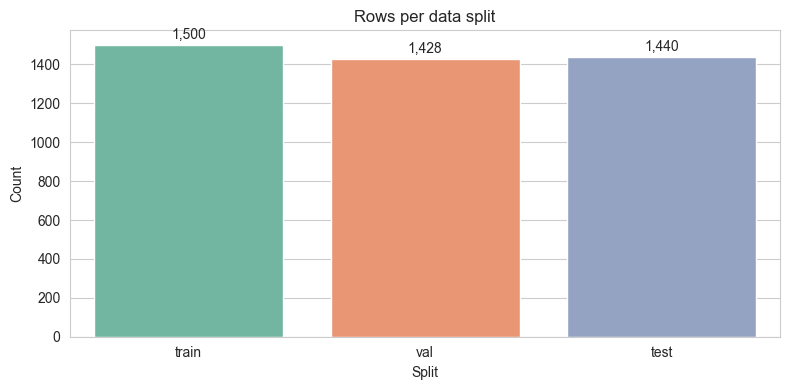

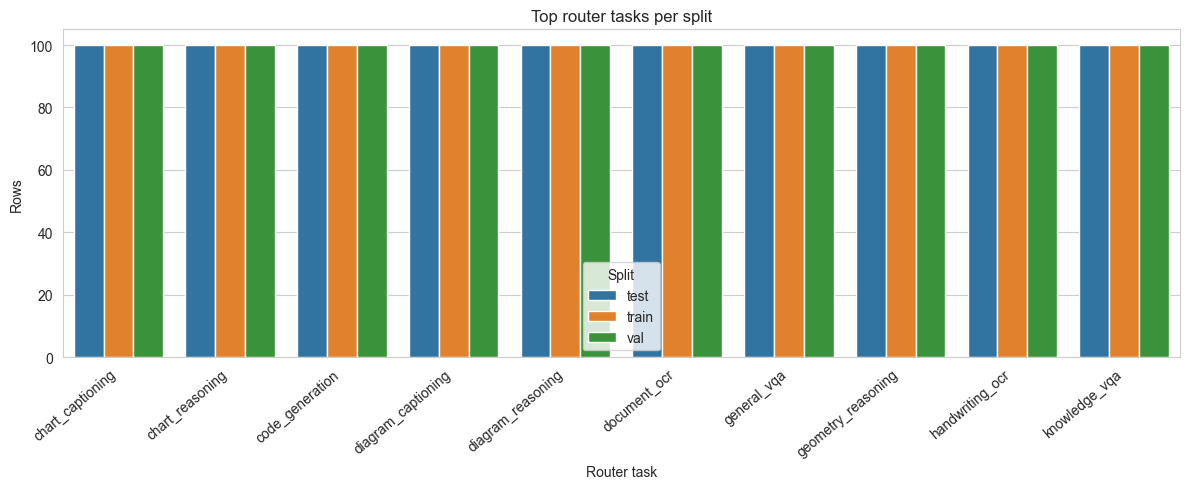

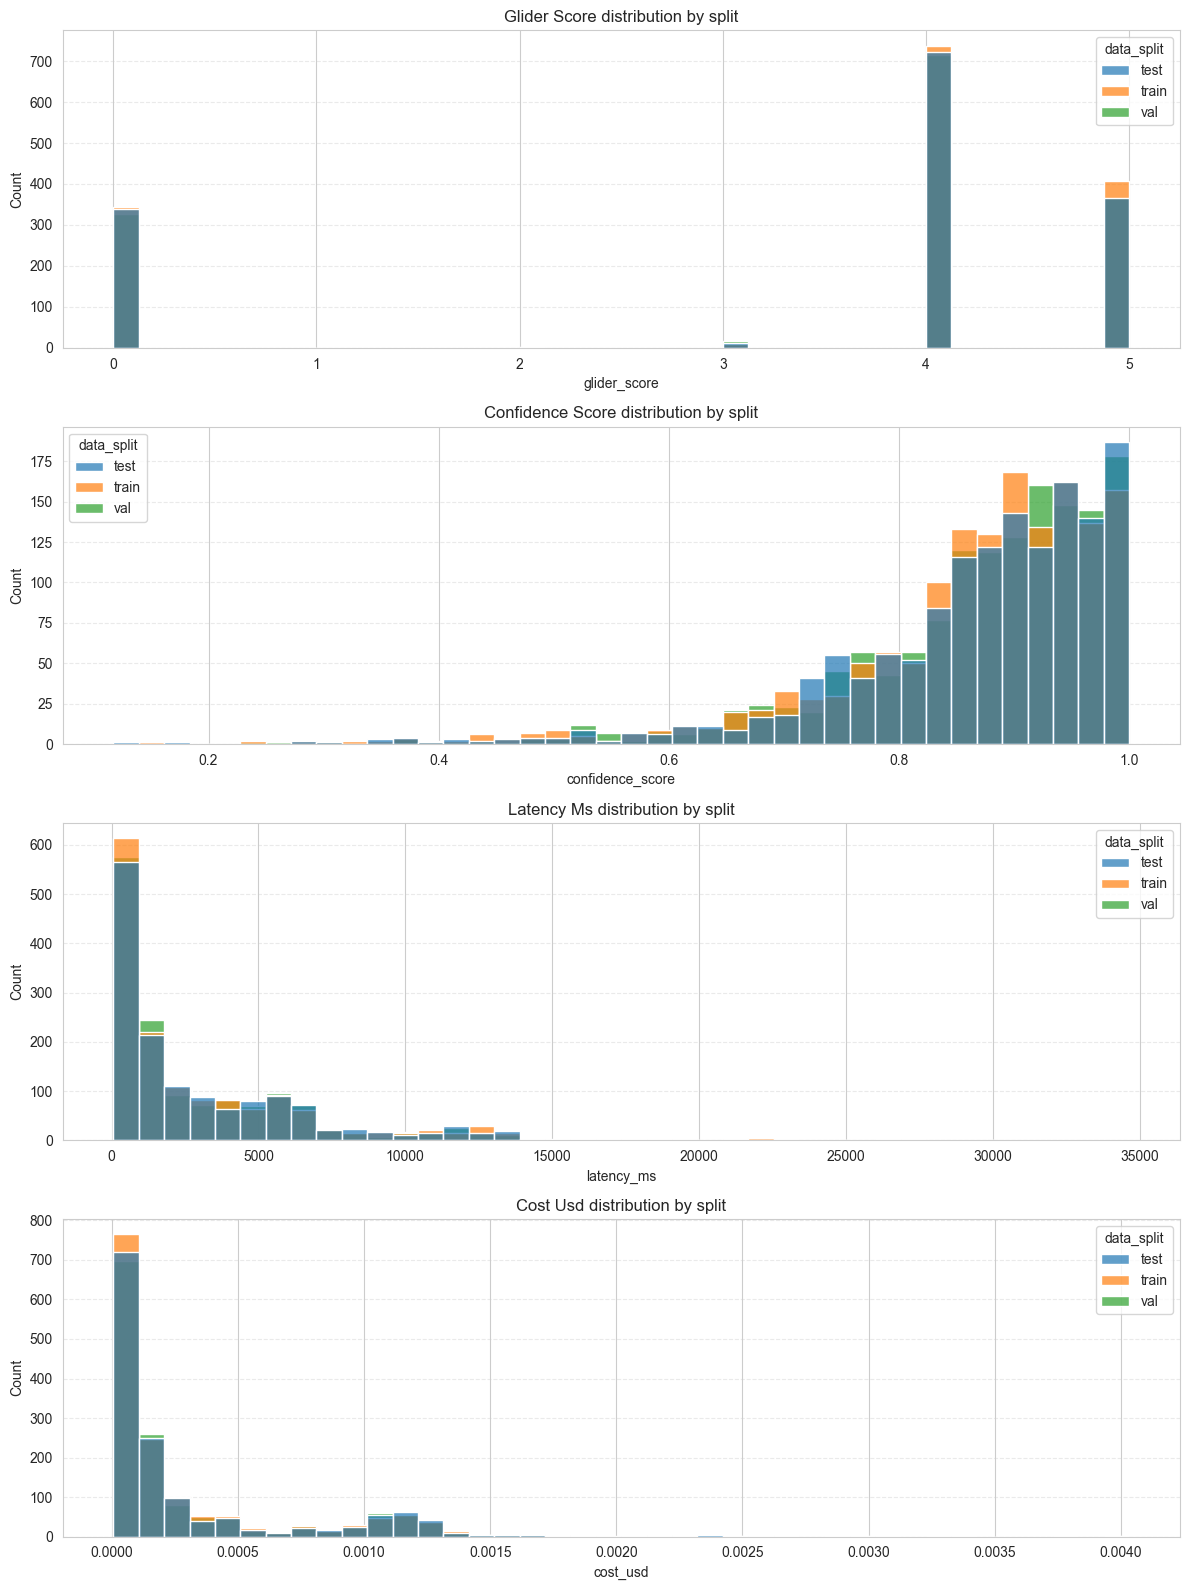

In [11]:
# Visualize split coverage and task/metric distributions
if 'data_split' not in df_clean.columns:
    print("⚠️  'data_split' column missing; skip visualization of splits.")
else:
    split_counts = df_clean['data_split'].value_counts()
    ordered_splits = ['train', 'val', 'test']
    ordered_splits += [split for split in split_counts.index if split not in ordered_splits]
    split_counts = split_counts.reindex(ordered_splits).fillna(0).astype(int)

    print("[Data split counts]")
    print(split_counts)

    fig, ax = plt.subplots(figsize=(8, 4))
    sns.barplot(x=split_counts.index, y=split_counts.values, palette='Set2', ax=ax)
    ax.set_title('Rows per data split')
    ax.set_ylabel('Count')
    ax.set_xlabel('Split')
    y_offset = split_counts.max() * 0.01 if split_counts.max() > 0 else 1
    for idx, value in enumerate(split_counts.values):
        ax.text(idx, value + y_offset, f"{value:,}", ha='center', va='bottom')
    plt.tight_layout()

    if 'router_task' in df_clean.columns:
        task_counts = df_clean['router_task'].value_counts()
        top_tasks = task_counts.head(10).index.tolist()
        print("Top router tasks (by rows):")
        print(task_counts.head(8))

        task_split_df = (
            df_clean[df_clean['router_task'].isin(top_tasks)]
            .groupby(['router_task', 'data_split'])
            .size()
            .reset_index(name='count')
        )

        fig, ax = plt.subplots(figsize=(12, 5))
        sns.barplot(
            data=task_split_df,
            x='router_task',
            y='count',
            hue='data_split',
            order=top_tasks,
            ax=ax,
        )
        ax.set_title('Top router tasks per split')
        ax.set_ylabel('Rows')
        ax.set_xlabel('Router task')
        ax.legend(title='Split')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right')
        plt.tight_layout()
    else:
        print("⚠️  'router_task' column missing; skipping task-level chart.")

    metric_columns = [col for col in ['glider_score', 'confidence_score', 'latency_ms', 'cost_usd'] if col in df_clean.columns]
    if metric_columns:
        fig, axes = plt.subplots(len(metric_columns), 1, figsize=(12, 4 * len(metric_columns)), sharex=False)
        if len(metric_columns) == 1:
            axes = [axes]
        for col, ax in zip(metric_columns, axes):
            sns.histplot(
                data=df_clean,
                x=col,
                hue='data_split',
                multiple='layer',
                stat='count',
                bins=40,
                edgecolor='w',
                alpha=0.7,
                ax=ax,
            )
            ax.set_title(f"{col.replace('_', ' ').title()} distribution by split")
            ax.set_ylabel('Count')
            ax.grid(True, axis='y', linestyle='--', alpha=0.4)
        plt.tight_layout()
    else:
        print("⚠️  No numeric metrics found for histogram visualization.")


## 7. Save to Local SQLite Database

In [12]:
# Save to SQLite
print(f"\n{'='*80}")
print("SAVING TO LOCAL SQLITE DATABASE")
print(f"{'='*80}\n")

print(f"[Saving to SQLite]")
print(f"  Path: {LOCAL_DB_PATH}")
print(f"  Table: {TABLE_NAME}")
print(f"  Rows: {len(df_clean):,}")
print(f"  Columns: {len(df_clean.columns)}")
print()

save_to_sqlite(
    df=df_clean,
    db_path=LOCAL_DB_PATH,
    table_name=TABLE_NAME,
    if_exists='replace',
)

# Get file size
file_size_mb = LOCAL_DB_PATH.stat().st_size / (1024 * 1024)

print(f"\n{'='*80}")
print("SAVE COMPLETE")
print(f"{'='*80}")
print(f"  Database file: {LOCAL_DB_PATH}")
print(f"  File size: {file_size_mb:.2f} MB")
print(f"  Rows saved: {len(df_clean):,}")
print(f"  Table name: {TABLE_NAME}")
print(f"{'='*80}")

print(f"\n✓ Local database ready!")

2025-12-07 00:40:33,383 - db_utils - INFO - Created SQLite engine for ../data/vlm_router_cache.db
2025-12-07 00:40:33,383 - db_utils - INFO - Saving 4368 rows to ../data/vlm_router_cache.db:vlm_profiles
2025-12-07 00:40:33,413 - db_utils - INFO - ✓ Saved to ../data/vlm_router_cache.db



SAVING TO LOCAL SQLITE DATABASE

[Saving to SQLite]
  Path: ../data/vlm_router_cache.db
  Table: vlm_profiles
  Rows: 4,368
  Columns: 17


SAVE COMPLETE
  Database file: ../data/vlm_router_cache.db
  File size: 2.20 MB
  Rows saved: 4,368
  Table name: vlm_profiles

✓ Local database ready!


## 8. Verify Local Database

In [13]:
# Test loading from SQLite
print(f"\n{'='*80}")
print("VERIFYING LOCAL DATABASE")
print(f"{'='*80}\n")

print("[Loading from SQLite (verification)]")
df_verify = load_from_sqlite(
    db_path=LOCAL_DB_PATH,
    table_name=TABLE_NAME,
    limit=10,  # Just load 10 rows for verification
)

print(f"\n[Verification Results]")
print(f"  Loaded {len(df_verify)} rows (limit=10)")
print(f"  Columns match: {set(df_verify.columns) == set(df_clean.columns)}")

print(f"\n[Sample Data]")
display(df_verify.head())

print(f"\n✓ Local database verified successfully!")

2025-12-07 00:40:33,418 - db_utils - INFO - Created SQLite engine for ../data/vlm_router_cache.db
2025-12-07 00:40:33,418 - db_utils - INFO - Loading from ../data/vlm_router_cache.db:vlm_profiles
2025-12-07 00:40:33,418 - db_utils - INFO -   Limit: 10
2025-12-07 00:40:33,420 - db_utils - INFO - Loaded 10 rows
2025-12-07 00:40:33,420 - db_utils - INFO -   Unique samples: 3
2025-12-07 00:40:33,420 - db_utils - INFO -   Unique models: 5
2025-12-07 00:40:33,420 - db_utils - INFO -   Data splits: {'test': 10}



VERIFYING LOCAL DATABASE

[Loading from SQLite (verification)]

[Verification Results]
  Loaded 10 rows (limit=10)
  Columns match: True

[Sample Data]


,sample_id,source_config,source_dataset,router_task,data_split,prompt_raw,txt_prompt_length_chars,txt_prompt_length_words,img_width,img_height,img_aspect_ratio,model_name,model_prefix,latency_ms,cost_usd,confidence_score,glider_score
0,chart2text_0_68249402,chart2text,cauldron,chart_captioning,test,Could you shed some light on the insights conv...,65,12,800,776,1.030928,gemma_3_27b,m5,10272.0,0.000097,0.832087,5.0
1,chart2text_0_68249402,chart2text,cauldron,chart_captioning,test,Could you shed some light on the insights conv...,65,12,800,776,1.030928,qwen2_5_vl_7b,m3,8598.0,0.000246,0.760264,4.0
2,chart2text_0_68249402,chart2text,cauldron,chart_captioning,test,Could you shed some light on the insights conv...,65,12,800,776,1.030928,deepseek_ocr,m1,1254.0,0.000037,0.996436,0.0
3,chart2text_0_68249402,chart2text,cauldron,chart_captioning,test,Could you shed some light on the insights conv...,65,12,800,776,1.030928,qwen2_5_vl_3b,m2,6152.0,0.000098,0.831460,4.0
4,chart2text_0_68249402,chart2text,cauldron,chart_captioning,test,Could you shed some light on the insights conv...,65,12,800,776,1.030928,qwen3_vl_8b_thinking,m4,5033.0,0.001188,0.865371,4.0



✓ Local database verified successfully!


## 9. Test Loading by Split

In [14]:
# Test loading each split
if 'data_split' in df_clean.columns:
    print(f"\n{'='*80}")
    print("TESTING SPLIT LOADING")
    print(f"{'='*80}\n")

    for split in ['train', 'val', 'test']:
        print(f"[Loading {split} split]")
        df_split = load_from_sqlite(
            db_path=LOCAL_DB_PATH,
            table_name=TABLE_NAME,
            data_split=split,
            limit=5,
        )
        print(f"  ✓ Loaded {len(df_split)} rows (limit=5)")
        print()

    print(f"✓ All splits can be loaded successfully!")
else:
    print(f"\nSkipping split loading test (no data_split column)")

2025-12-07 00:40:33,431 - db_utils - INFO - Created SQLite engine for ../data/vlm_router_cache.db
2025-12-07 00:40:33,431 - db_utils - INFO - Loading from ../data/vlm_router_cache.db:vlm_profiles
2025-12-07 00:40:33,431 - db_utils - INFO -   Filtering by data_split: train
2025-12-07 00:40:33,431 - db_utils - INFO -   Limit: 5
2025-12-07 00:40:33,433 - db_utils - INFO - Loaded 5 rows
2025-12-07 00:40:33,433 - db_utils - INFO -   Unique samples: 2
2025-12-07 00:40:33,433 - db_utils - INFO -   Unique models: 4
2025-12-07 00:40:33,434 - db_utils - INFO -   Data splits: {'train': 5}
2025-12-07 00:40:33,434 - db_utils - INFO - Created SQLite engine for ../data/vlm_router_cache.db
2025-12-07 00:40:33,434 - db_utils - INFO - Loading from ../data/vlm_router_cache.db:vlm_profiles
2025-12-07 00:40:33,435 - db_utils - INFO -   Filtering by data_split: val
2025-12-07 00:40:33,435 - db_utils - INFO -   Limit: 5
2025-12-07 00:40:33,436 - db_utils - INFO - Loaded 5 rows
2025-12-07 00:40:33,437 - db_ut


TESTING SPLIT LOADING

[Loading train split]
  ✓ Loaded 5 rows (limit=5)

[Loading val split]
  ✓ Loaded 5 rows (limit=5)

[Loading test split]
  ✓ Loaded 5 rows (limit=5)

✓ All splits can be loaded successfully!


## 10. Create Metadata File

In [15]:
# Save metadata about the database
import json

metadata = {
    'created_at': datetime.now().isoformat(),
    'source_host': db_config.host,
    'source_database': db_config.name,
    'total_rows': int(len(df_clean)),
    'unique_samples': int(df_clean['sample_id'].nunique()),
    'unique_models': int(df_clean['model_name'].nunique()),
    'models': sorted(df_clean['model_name'].unique().tolist()),
    'columns': df_clean.columns.tolist(),
    'table_name': TABLE_NAME,
    'cleaning_stats': cleaning_stats,
}

if 'data_split' in df_clean.columns:
    metadata['split_counts'] = df_clean['data_split'].value_counts().to_dict()

metadata_path = DATA_DIR / "vlm_router_cache_metadata.json"
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"\n[Metadata Saved]")
print(f"  Path: {metadata_path}")
print(f"\nMetadata:")
print(json.dumps(metadata, indent=2))


[Metadata Saved]
  Path: ../data/vlm_router_cache_metadata.json

Metadata:
{
  "created_at": "2025-12-07T00:40:33.444609",
  "source_host": "localhost",
  "source_database": "vlmrouter",
  "total_rows": 4368,
  "unique_samples": 1090,
  "unique_models": 5,
  "models": [
    "deepseek_ocr",
    "gemma_3_27b",
    "qwen2_5_vl_3b",
    "qwen2_5_vl_7b",
    "qwen3_vl_8b_thinking"
  ],
  "columns": [
    "sample_id",
    "source_config",
    "source_dataset",
    "router_task",
    "data_split",
    "prompt_raw",
    "txt_prompt_length_chars",
    "txt_prompt_length_words",
    "img_width",
    "img_height",
    "img_aspect_ratio",
    "model_name",
    "model_prefix",
    "latency_ms",
    "cost_usd",
    "confidence_score",
    "glider_score"
  ],
  "table_name": "vlm_profiles",
  "cleaning_stats": {
    "initial_rows": 4368,
    "dropped_rows": 0,
    "filled_cost": 0,
    "filled_latency": 0,
    "filled_confidence": 0,
    "final_rows": 4368
  },
  "split_counts": {
    "train": 1500,

## 11. Usage Instructions

In [16]:
# Print usage instructions
print(f"\n{'='*80}")
print("SETUP COMPLETE - HOW TO USE")
print(f"{'='*80}\n")

print("The local database is ready! In your training notebooks (02, 03, 04), replace:")
print()
print("  # OLD: Load from PostgreSQL")
print("  df_profiles = load_profiles_real_schema(")
print("      db_config=db_config,")
print("      data_split='train',")
print("  )")
print()
print("  # NEW: Load from local SQLite")
print("  from db_utils import load_from_sqlite")
print()
print(f"  LOCAL_DB_PATH = Path('../data/vlm_router_cache.db')")
print()
print("  df_profiles = load_from_sqlite(")
print("      db_path=LOCAL_DB_PATH,")
print("      table_name='vlm_profiles',")
print("      data_split='train',  # or 'val', 'test', or None for all")
print("  )")
print()
print(f"{'='*80}")
print(f"\n✓ You can now run notebooks 02, 03, 04 using the local database!")
print(f"\n💡 Tip: Re-run this notebook whenever you want to refresh the local cache.")
print(f"{'='*80}")


SETUP COMPLETE - HOW TO USE

The local database is ready! In your training notebooks (02, 03, 04), replace:

  # OLD: Load from PostgreSQL
  df_profiles = load_profiles_real_schema(
      db_config=db_config,
      data_split='train',
  )

  # NEW: Load from local SQLite
  from db_utils import load_from_sqlite

  LOCAL_DB_PATH = Path('../data/vlm_router_cache.db')

  df_profiles = load_from_sqlite(
      db_path=LOCAL_DB_PATH,
      table_name='vlm_profiles',
      data_split='train',  # or 'val', 'test', or None for all
  )


✓ You can now run notebooks 02, 03, 04 using the local database!

💡 Tip: Re-run this notebook whenever you want to refresh the local cache.


## Summary

This notebook:
1. ✅ Connected to PostgreSQL
2. ✅ Fetched all profiling data
3. ✅ Validated data quality
4. ✅ Cleaned missing values
5. ✅ Validated train/val/test splits
6. ✅ Visualized split coverage and key metrics
7. ✅ Saved to local SQLite database
8. ✅ Verified the local database works

### Files Created

- `../data/vlm_router_cache.db` - Local SQLite database with all data
- `../data/vlm_router_cache_metadata.json` - Metadata about the cache

### Next Steps

1. Update notebooks 02, 03, 04 to use `load_from_sqlite()` instead of `load_profiles_real_schema()`
2. Run training notebooks - they'll be much faster!
3. Re-run this notebook whenever you need to refresh the cache with new data
